<a href="https://colab.research.google.com/github/Raulgmg1999/TELECOM-X-2/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos #

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X

In [31]:

import pandas as pd
df = pd.read_excel('/content/telecom_data.xlsx')
##cambiar columna churn a 0 y 1
df['churn'] = df['churn'].map({'No': 0, 'Yes': 1})
df.head(10)

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
5,0013-MHZWF,0,Female,0,0,1,9,1,0,DSL,...,0,1,1,1,Month-to-month,1,Credit card (automatic),69.40,571.45,2.313333
6,0013-SMEOE,0,Female,1,1,0,71,1,0,Fiber optic,...,1,1,1,1,Two year,1,Bank transfer (automatic),109.70,7904.25,3.656667
7,0014-BMAQU,0,Male,0,1,0,63,1,1,Fiber optic,...,0,1,0,0,Two year,1,Credit card (automatic),84.65,5377.80,2.821667
8,0015-UOCOJ,0,Female,1,0,0,7,1,0,DSL,...,0,0,0,0,Month-to-month,1,Electronic check,48.20,340.35,1.606667
9,0016-QLJIS,0,Female,0,1,1,65,1,1,DSL,...,1,1,1,1,Two year,1,Mailed check,90.45,5957.90,3.015000


Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [32]:
df.drop(columns=["customer_id"], inplace=True)

In [33]:
df.head()

,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   churn              7043 non-null   int64  
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   int64  
 4   dependents         7043 non-null   int64  
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   int64  
 7   multiple_lines     7043 non-null   int64  
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   int64  
 10  online_backup      7043 non-null   int64  
 11  device_protection  7043 non-null   int64  
 12  tech_support       7043 non-null   int64  
 13  streaming_tv       7043 non-null   int64  
 14  streaming_movies   7043 non-null   int64  
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:
Artículo en Alura sobre codificación categórica

In [38]:
df_encoded = pd.get_dummies(df, columns=['gender', 'internet_service', 'contract', 'payment_method'], drop_first=True, dtype=int)

print("Dimensiones del DataFrame original:", df.shape)
print("Dimensiones del DataFrame solo codificado (one-hot):", df_encoded.shape)
df_encoded.head()

Dimensiones del DataFrame original: (7043, 21)
Dimensiones del DataFrame solo codificado (one-hot): (7043, 25)


,churn,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,total_charges,cuentas_diarias,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.186667,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542.40,1.996667,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.463333,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.266667,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.796667,0,1,0,0,0,0,0,1


Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

# 🎯 Correlación y Selección de Variables  #

In [39]:
churn_proportion = df_encoded['churn'].value_counts(normalize=True)
churn_proportion



,proportion
churn,
0,0.73463
1,0.26537


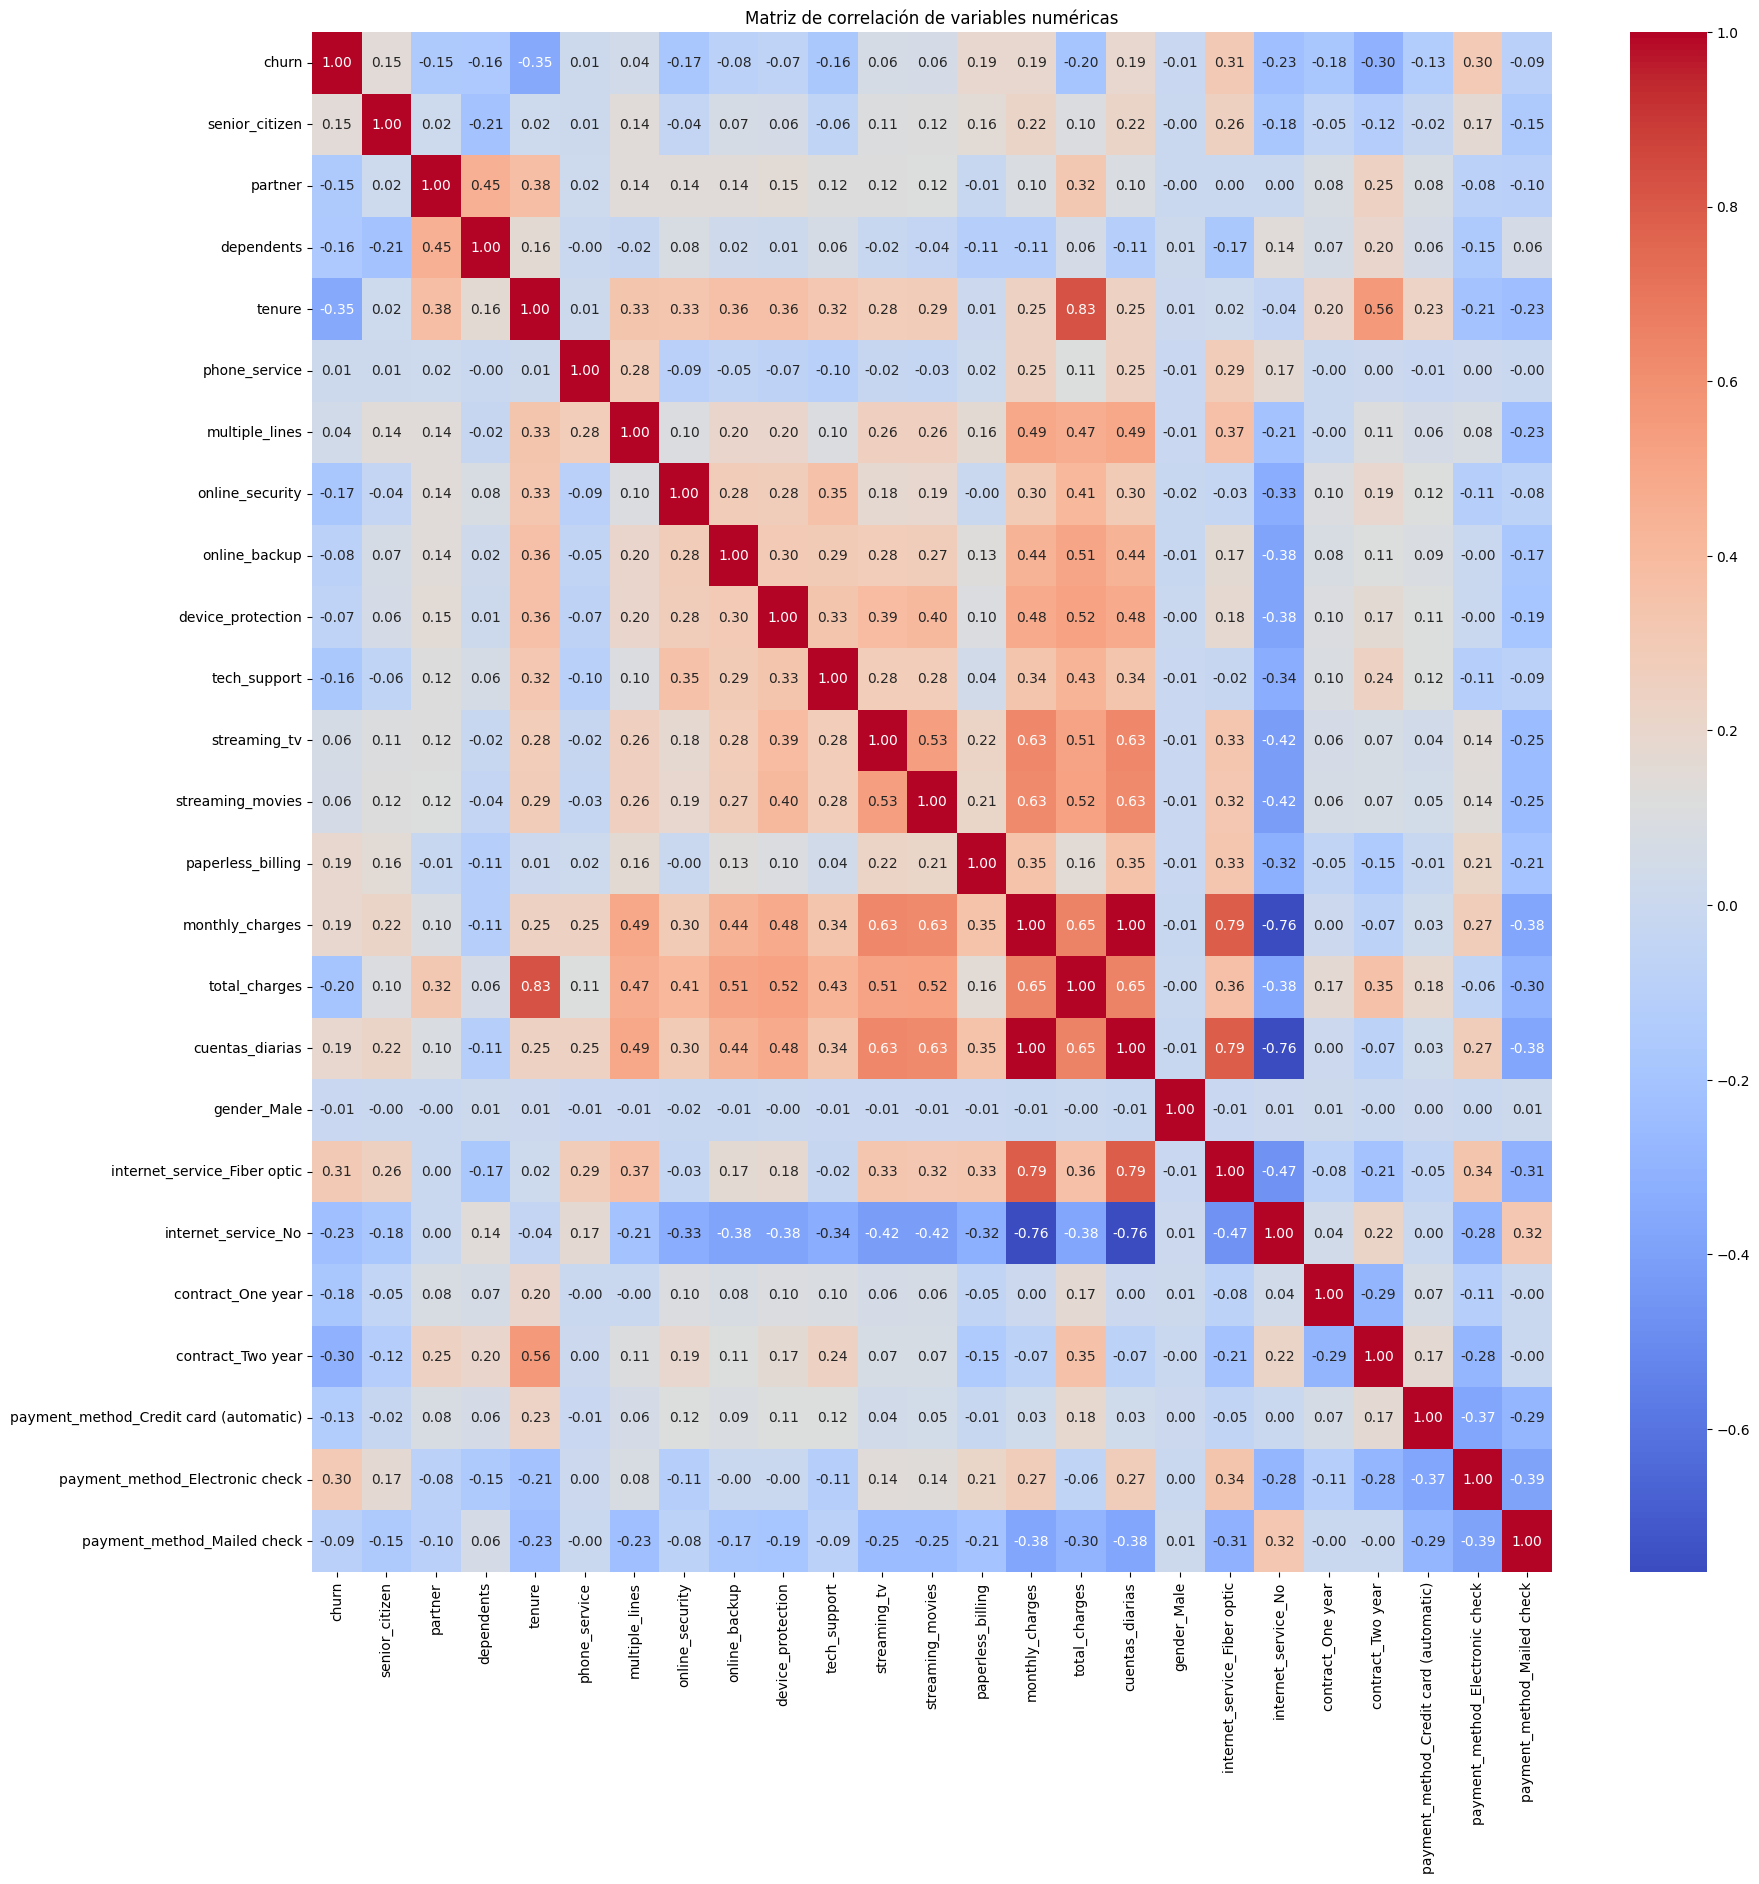

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_matrix = df_encoded.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

En la matriz de correlación se observa que la variable churn presenta una relación negativa con el tiempo de contrato (tenure) y con el gasto total (total charges). Esto indica que, conforme aumenta la antigüedad del cliente y el gasto acumulado, disminuye la probabilidad de cancelación.

También se aprecia que los contratos de mayor duración, como los de dos años, se asocian con menores niveles de churn, lo que sugiere que los compromisos a largo plazo favorecen la permanencia de los clientes. En general, la correlación confirma que los clientes con más tiempo en el servicio y mayor gasto acumulado tienden a cancelar menos.

In [52]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   churn                                   7043 non-null   int64  
 1   senior_citizen                          7043 non-null   int64  
 2   partner                                 7043 non-null   int64  
 3   dependents                              7043 non-null   int64  
 4   tenure                                  7043 non-null   int64  
 5   phone_service                           7043 non-null   int64  
 6   multiple_lines                          7043 non-null   int64  
 7   online_security                         7043 non-null   int64  
 8   online_backup                           7043 non-null   int64  
 9   device_protection                       7043 non-null   int64  
 10  tech_support                            7043 non-null   int6

In [53]:
df_encoded.describe()

,churn,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,total_charges,cuentas_diarias,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,2279.734304,2.158723,0.504756,0.439585,0.216669,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,2266.794470,1.003002,0.500013,0.496372,0.412004,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.608333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,398.550000,1.183333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1394.550000,2.345000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3786.600000,2.995000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,8684.800000,3.958333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


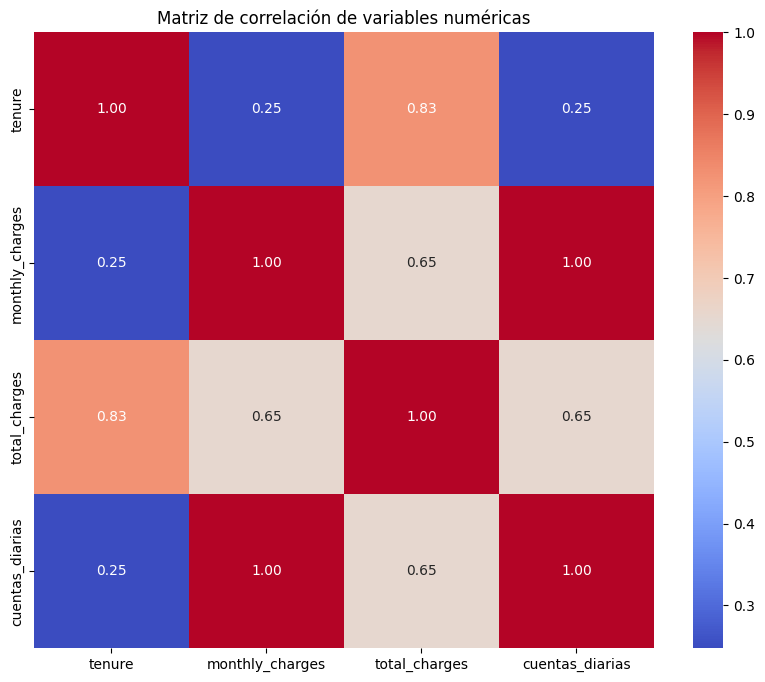

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar las columnas numéricas originales
numerical_cols = ['tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias']

# Calcular la matriz de correlación solo para las columnas numéricas
corr_matrix_numerical = df_encoded[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_numerical,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

Calculando correlación para las columnas: ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias', 'churn', 'paperless_billing']


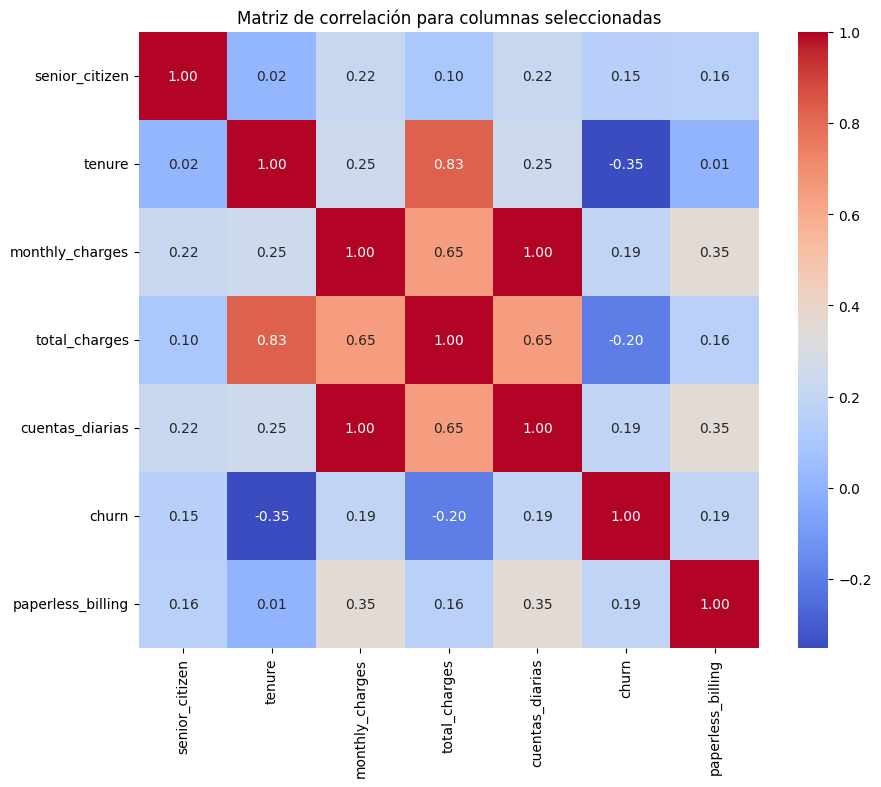

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

actual_columns = [
    'senior_citizen',
    'tenure',
    'monthly_charges',
    'total_charges',
    'cuentas_diarias',
    'churn',
    'paperless_billing'
]

print(f"Calculando correlación para las columnas: {actual_columns}")
# Calcular la matriz de correlación para las columnas seleccionadas
corr_matrix_selected = df_encoded[actual_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_selected,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación para columnas seleccionadas")
plt.show()

## Análisis Dirigido ##

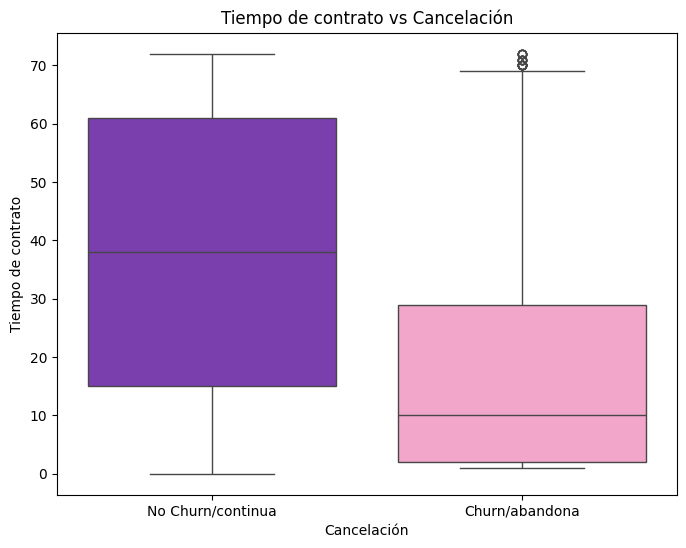

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_encoded['churn_labels'] = df_encoded['churn'].map({0:'No Churn/continua', 1:'Churn/abandona'})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_encoded, x='churn_labels',
            y='tenure',
            hue='churn_labels',
            palette=['#7b2cbf', '#ff99c8'])

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tiempo de contrato')
plt.show()

df_encoded.drop(columns=['churn_labels'], inplace=True)

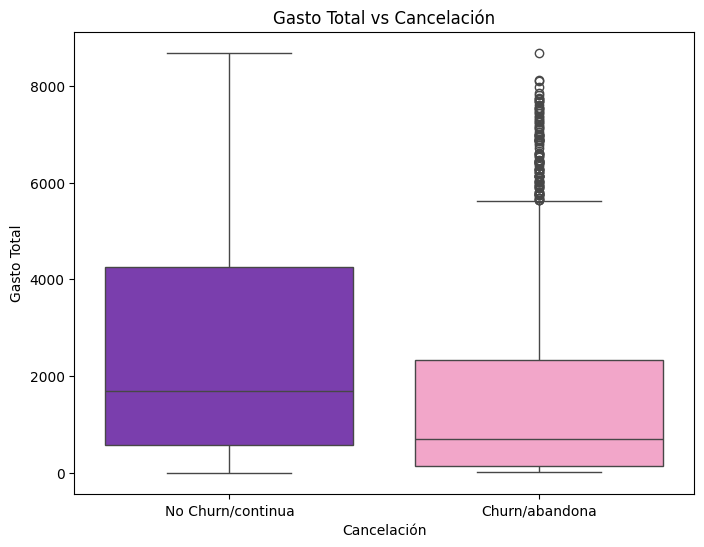

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded['churn_labels'] = df_encoded['churn'].map({0:'No Churn/continua', 1:'Churn/abandona'})

plt.figure(figsize = (8,6))
sns.boxplot(data = df_encoded, x = 'churn_labels',
            y = 'total_charges',
            hue = 'churn_labels',
            palette = ['#7b2cbf', '#ff99c8'],
            )
plt.title('Gasto Total vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Gasto Total')
plt.show()

df_encoded.drop(columns=['churn_labels'], inplace=True)

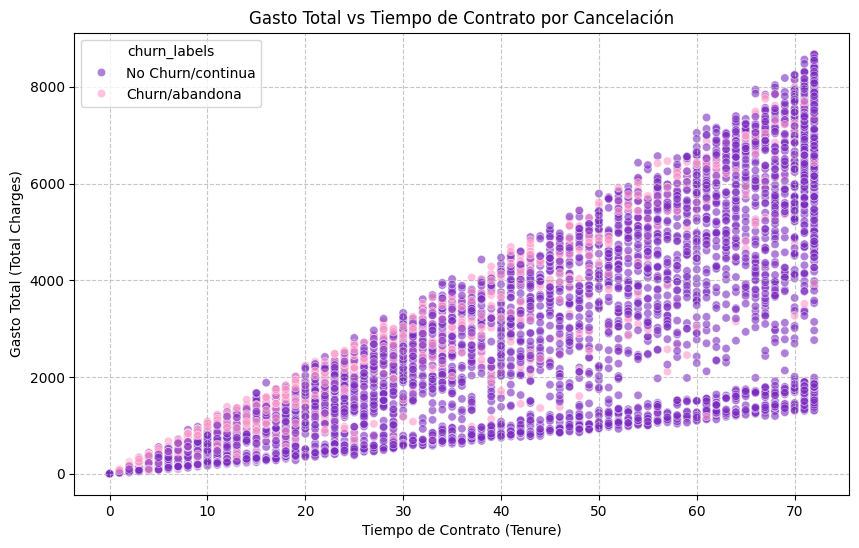

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df_encoded['churn_labels'] = df_encoded['churn'].map({0:'No Churn/continua', 1:'Churn/abandona'})

plt.figure(figsize = (10,6))
sns.scatterplot(data = df_encoded, x = 'tenure',
            y = 'total_charges',
            hue = 'churn_labels',
            palette = ['#7b2cbf', '#ff99c8'],
            alpha=0.6)
plt.title('Gasto Total vs Tiempo de Contrato por Cancelación')
plt.xlabel('Tiempo de Contrato (Tenure)')
plt.ylabel('Gasto Total (Total Charges)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

df_encoded.drop(columns=['churn_labels'], inplace=True)

A partir de las gráficas de dispersión y los diagramas de caja, se observa que los clientes que cancelan el servicio suelen tener menos meses de contrato en comparación con los que permanecen activos.

También se aprecia que el gasto total acumulado de los clientes que cancelan es menor, lo cual está relacionado con su menor tiempo de permanencia en el servicio.

En general, las gráficas muestran una tendencia clara: a mayor tiempo de contrato, mayor gasto total acumulado y menor probabilidad de churn. Esto sugiere que los primeros meses del cliente son el periodo donde existe mayor riesgo de cancelación.

# 🤖 Modelado Predictivo #

## Separación de datos ##

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [59]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Creación de modelos ##

rea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**En mi caso sera arbol de decisón y random forest**

Arbol

In [66]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Random

In [67]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predicciones

In [68]:
y_pred_tree = tree_model.predict(X_test)

In [69]:
y_pred_rf = rf_model.predict(X_test)

## Evaluar modelos ##

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

### Arbol ###

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [71]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Árbol de Decisión")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)

Árbol de Decisión
Accuracy: 0.7366926898509581
Precision: 0.5026315789473684
Recall: 0.5120643431635389
F1-score: 0.5073041168658698


In [72]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Matriz de confusión - Árbol de Decisión")
print(cm_tree)

Matriz de confusión - Árbol de Decisión
[[847 189]
 [182 191]]


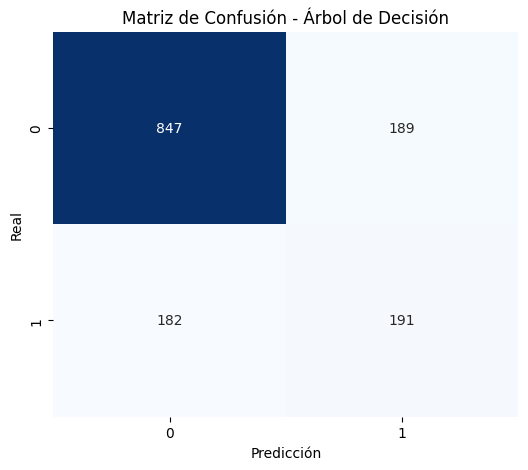

In [77]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

Random

In [74]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest
Accuracy: 0.7920511000709723
Precision: 0.6481481481481481
Recall: 0.4691689008042895
F1-score: 0.5443234836702955


Matriz de confusión - Random Forest
[[941  95]
 [198 175]]


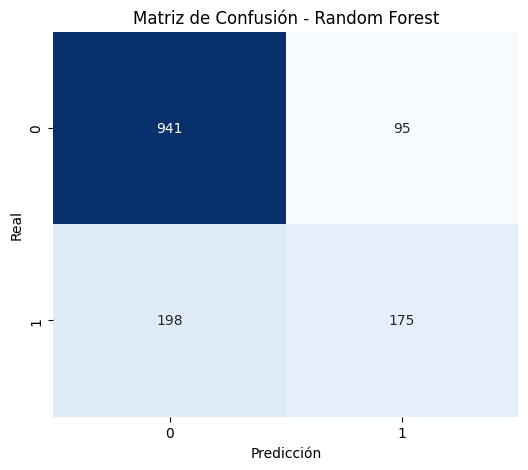

In [76]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de confusión - Random Forest")
print(cm_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# 📋 Interpretación y Conclusiones  #

## Análisis de la Importancia de las Variables ##

### arbol ###

In [78]:
import pandas as pd

importance_tree = pd.DataFrame({
    'variable': X_train.columns,
    'importance': tree_model.feature_importances_
})

In [79]:
importance_tree = importance_tree.sort_values(by='importance', ascending=False)
importance_tree

,variable,importance
3,tenure,0.200664
14,total_charges,0.191507
17,internet_service_Fiber optic,0.105952
15,cuentas_diarias,0.101492
13,monthly_charges,0.094311
22,payment_method_Electronic check,0.025369
20,contract_Two year,0.023459
16,gender_Male,0.022605
2,dependents,0.021237
1,partner,0.020964


In [80]:
importance_tree.head(10)

,variable,importance
3,tenure,0.200664
14,total_charges,0.191507
17,internet_service_Fiber optic,0.105952
15,cuentas_diarias,0.101492
13,monthly_charges,0.094311
22,payment_method_Electronic check,0.025369
20,contract_Two year,0.023459
16,gender_Male,0.022605
2,dependents,0.021237
1,partner,0.020964


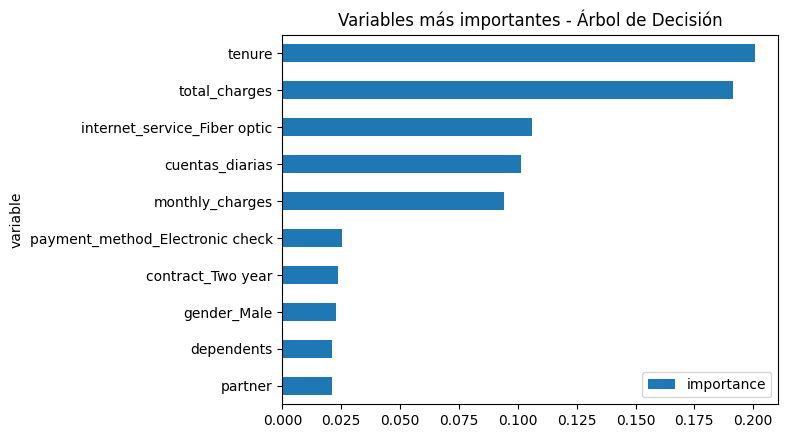

In [81]:
import matplotlib.pyplot as plt

importance_tree.head(10).plot(
    x='variable',
    y='importance',
    kind='barh'
)

plt.title("Variables más importantes - Árbol de Decisión")
plt.gca().invert_yaxis()
plt.show()

In [82]:
top_variables = importance_tree.head(10)['variable']
top_variables

,variable
3,tenure
14,total_charges
17,internet_service_Fiber optic
15,cuentas_diarias
13,monthly_charges
22,payment_method_Electronic check
20,contract_Two year
16,gender_Male
2,dependents
1,partner


In [85]:
## entrenamos nuevamente

X_train_top = X_train[top_variables]
X_test_top = X_test[top_variables]

tree_model_top = DecisionTreeClassifier(random_state=42)
tree_model_top.fit(X_train_top, y_train)

DecisionTreeClassifier(random_state=42)

In [86]:
y_pred_tree_top = tree_model_top.predict(X_test_top)

In [87]:
from sklearn.metrics import accuracy_score

accuracy_tree_top = accuracy_score(y_test, y_pred_tree_top)
print("Accuracy Árbol de Decisión con variables importantes:", accuracy_tree_top)

Accuracy Árbol de Decisión con variables importantes: 0.7239176721078779


### Random Forest ###

In [88]:
importance_rf = rf_model.feature_importances_

In [89]:
importance_rf_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importance_rf
})

In [90]:
importance_rf_df = importance_rf_df.sort_values(by='Importancia', ascending=False)
importance_rf_df

,Variable,Importancia
14,total_charges,0.171253
3,tenure,0.149164
15,cuentas_diarias,0.136662
13,monthly_charges,0.136204
17,internet_service_Fiber optic,0.039011
20,contract_Two year,0.036734
22,payment_method_Electronic check,0.035664
19,contract_One year,0.024917
16,gender_Male,0.024189
12,paperless_billing,0.023200


In [92]:
importance_rf_df.head(10)

,Variable,Importancia
14,total_charges,0.171253
3,tenure,0.149164
15,cuentas_diarias,0.136662
13,monthly_charges,0.136204
17,internet_service_Fiber optic,0.039011
20,contract_Two year,0.036734
22,payment_method_Electronic check,0.035664
19,contract_One year,0.024917
16,gender_Male,0.024189
12,paperless_billing,0.023200


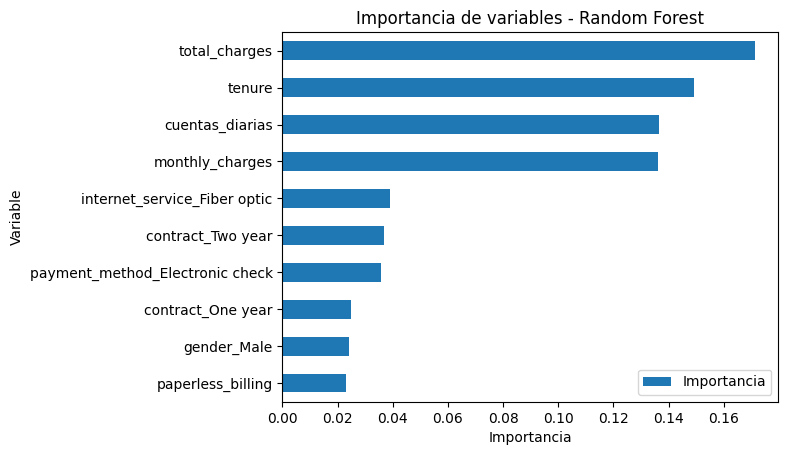

In [93]:
import matplotlib.pyplot as plt

importance_rf_df.head(10).plot(
    x='Variable',
    y='Importancia',
    kind='barh'
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

In [94]:
top_variables_rf = importance_rf_df.head(10)['Variable']
top_variables_rf

,Variable
14,total_charges
3,tenure
15,cuentas_diarias
13,monthly_charges
17,internet_service_Fiber optic
20,contract_Two year
22,payment_method_Electronic check
19,contract_One year
16,gender_Male
12,paperless_billing


In [95]:
X_train_rf_top = X_train[top_variables_rf]
X_test_rf_top = X_test[top_variables_rf]

from sklearn.ensemble import RandomForestClassifier
rf_model_top = RandomForestClassifier(random_state=42)

In [96]:
rf_model_top.fit(X_train_rf_top, y_train)

RandomForestClassifier(random_state=42)

In [97]:
y_pred_rf_top = rf_model_top.predict(X_test_rf_top)

In [98]:
from sklearn.metrics import accuracy_score

accuracy_rf_top = accuracy_score(y_test, y_pred_rf_top)
print("Accuracy Random Forest con variables importantes:", accuracy_rf_top)

Accuracy Random Forest con variables importantes: 0.7757274662881476


## Conclusión ##

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

## informe ##

**CONCLUSIÓN**

En este proyecto se analizaron distintas variables para entender la cancelación de clientes. En el análisis exploratorio se observó que variables como tenure, monthly charges y total charges tienen una relación importante con el churn. En general, los clientes con menos tiempo en el servicio presentan mayor probabilidad de cancelar.

Se entrenaron dos modelos de clasificación: Árbol de Decisión y Random Forest. Al evaluar los modelos con métricas como accuracy, precision, recall y F1-score, se observó que Random Forest obtuvo mejores resultados, mostrando un mejor equilibrio entre las métricas y una mayor capacidad de generalización.

Además, el análisis de importancia de variables indicó que tenure, monthly charges y el tipo de contrato son algunos de los factores que más influyen en la predicción de cancelación. Esto coincide con lo observado en el análisis exploratorio.

En general, Random Forest resultó ser el modelo más adecuado para este problema, ya que logró un mejor desempeño y permitió identificar variables relevantes que pueden ayudar a entender mejor el comportamiento de cancelación de los clientes.